# List 1

**Introduction to tools for data analysis and classification model building**

In the following tasks you will use the *Adult* dataset available in the `sklearn` library.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score, make_scorer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn

In [2]:
from sklearn.datasets import fetch_openml
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame

In this version of the dataset, the target variable is the `class` column.
While completing the tasks, you should use the following libraries: `pandas`, `matplotlib`, `sklearn`, and `torch`.

---

## 1. EDA — pandas

The goal of this section is to become familiar with basic operations on a `DataFrame`.

### Task 1 — Basic information

1. Print the number of rows and columns in the dataset.
2. Print the names of all columns.
3. Check the number of missing values in each column.
4. Display descriptive statistics for numerical columns using the appropriate `pandas` method.

In [3]:
rows = df.shape[0]
cols = df.shape[1]
print(f'Cols: {cols}')
print(f'Rows: {rows}')

Cols: 15
Rows: 48842


In [4]:
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')


In [5]:
for col in df.columns:
    print(col, ":", df[col].isna().sum())

age : 0
workclass : 2799
fnlwgt : 0
education : 0
education-num : 0
marital-status : 0
occupation : 2809
relationship : 0
race : 0
sex : 0
capital-gain : 0
capital-loss : 0
hours-per-week : 0
native-country : 857
class : 0


In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### Task 2 — Category counts

1. Compute the number of observations in each category of the `education` variable.
2. Sort the result in descending order by count.
3. Print the five most frequent categories.

In [7]:
df['education'].value_counts().sort_values(ascending=False).iloc[0:5]

,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061


### Task 3 — Grouping and aggregation

For each category of the `education` variable, compute:

* the mean value of `hours-per-week`,
* the mean value of `capital-gain`,
* the percentage of observations belonging to the `>50K` class (based on the `class` column).

Use the `groupby()` and `agg()` methods.

In [8]:
df.groupby(['education'])['hours-per-week'].agg('mean')

/tmp/ipython-input-391/1614805880.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['education'])['hours-per-week'].agg('mean')


,hours-per-week
education,
10th,36.986321
11th,33.952539
12th,35.374429
1st-4th,38.761134
5th-6th,38.923379
7th-8th,39.003141
9th,38.359788
Assoc-acdm,40.809494
Assoc-voc,41.658418


In [9]:
df.groupby(['education'])['capital-gain'].agg('mean')

/tmp/ipython-input-391/1865445421.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['education'])['capital-gain'].agg('mean')


,capital-gain
education,
10th,323.049676
11th,203.739514
12th,208.579909
1st-4th,123.591093
5th-6th,360.365422
7th-8th,242.626178
9th,313.398148
Assoc-acdm,636.951905
Assoc-voc,778.602135


In [10]:
df.groupby(['education'])['class'].agg(lambda x: x.value_counts()['>50K'] / len(x))

/tmp/ipython-input-391/3751867479.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['education'])['class'].agg(lambda x: x.value_counts()['>50K'] / len(x))


,class
education,
10th,0.062635
11th,0.050773
12th,0.073059
1st-4th,0.032389
5th-6th,0.053045
7th-8th,0.064921
9th,0.054233
Assoc-acdm,0.257964
Assoc-voc,0.253275


### Task 4 — Filtering data

1. Select observations for which `capital-gain > 0`.
2. Compute the mean `hours-per-week` for this group.
3. Compute the mean `hours-per-week` for observations with `capital-gain == 0`.

In [11]:
df[df['capital-gain'] > 0]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
10,65,Private,184454,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,6418,0,40,United-States,>50K
14,48,Private,279724,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,3103,0,48,United-States,>50K
25,45,Self-emp-not-inc,432824,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,90,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48796,66,Federal-gov,47358,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,3471,0,40,United-States,<=50K
48799,57,Local-gov,110417,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,40,United-States,>50K
48819,38,Private,139180,Bachelors,13,Divorced,Prof-specialty,Unmarried,Black,Female,15020,0,45,United-States,>50K
48829,65,Self-emp-not-inc,99359,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,1086,0,60,United-States,<=50K


In [12]:
df[df['capital-gain'] > 0]['hours-per-week'].mean()

np.float64(43.52614622057001)

In [13]:
df[df['capital-gain'] == 0]['hours-per-week'].mean()

np.float64(40.14287946079853)

### Task 5 — Creating a new column

1. Create a new column called `hours_bucket` by dividing `hours-per-week` into intervals of 10 hours using `pd.cut`.
2. Compute the number of observations in each interval.
3. Create a pivot table in which:

   * the index is `hours_bucket`,
   * the columns correspond to `class`,
   * the values represent the number of observations.

In [14]:
df['hours_bucket'] = pd.cut(df['hours-per-week'], 10)
df['hours_bucket']

,hours_bucket
0,"(30.4, 40.2]"
1,"(40.2, 50.0]"
2,"(30.4, 40.2]"
3,"(30.4, 40.2]"
4,"(20.6, 30.4]"
...,...
48837,"(30.4, 40.2]"
48838,"(30.4, 40.2]"
48839,"(30.4, 40.2]"
48840,"(10.8, 20.6]"


In [15]:
df['hours_bucket'].value_counts()

,count
hours_bucket,
"(30.4, 40.2]",26639
"(40.2, 50.0]",8917
"(20.6, 30.4]",3398
"(10.8, 20.6]",3328
"(59.8, 69.6]",2642
"(50.0, 59.8]",1582
"(0.902, 10.8]",1125
"(69.6, 79.4]",683
"(79.4, 89.2]",315


In [16]:
pd.pivot_table(df, index='hours_bucket', columns='class', aggfunc='count')

/tmp/ipython-input-391/3422264655.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df, index='hours_bucket', columns='class', aggfunc='count')


age       capital-gain       capital-loss       education  \
class          <=50K  >50K        <=50K  >50K        <=50K  >50K     <=50K   
hours_bucket                                                                 
(0.902, 10.8]   1020   105         1020   105         1020   105      1020   
(10.8, 20.6]    3132   196         3132   196         3132   196      3132   
(20.6, 30.4]    3173   225         3173   225         3173   225      3173   
(30.4, 40.2]   21220  5419        21220  5419        21220  5419     21220   
(40.2, 50.0]    5398  3519         5398  3519         5398  3519      5398   
(50.0, 59.8]     912   670          912   670          912   670       912   
(59.8, 69.6]    1511  1131         1511  1131         1511  1131      1511   
(69.6, 79.4]     444   239          444   239          444   239       444   
(79.4, 89.2]     197   118          197   118          197   118       197   
(89.2, 99.0]     148    65          148    65          148    65       148   

                    education-num        ... occupation         race        \
class          >50K         <=50K  >50K  ...      <=50K  >50K  <=50K  >50K   
hours_bucket                             ...                                 
(0.902, 10.8]   105          1020   105  ...        726    68   1020   105   
(10.8, 20.6]    196          3132   196  ...       2699   165   3132   196   
(20.6, 30.4]    225          3173   225  ...       2781   205   3173   225   
(30.4, 40.2]   5419         21220  5419  ...      20052  5312  21220  5419   
(40.2, 50.0]   3519          5398  3519  ...       5247  3476   5398  3519   
(50.0, 59.8]    670           912   670  ...        889   662    912   670   
(59.8, 69.6]   1131          1511  1131  ...       1471  1119   1511  1131   
(69.6, 79.4]    239           444   239  ...        428   237    444   239   
(79.4, 89.2]    118           197   118  ...        181   114    197   118   
(89.2, 99.0]     65           148    65  ...        137    64    148    65   

              relationship          sex       workclass        
class                <=50K  >50K  <=50K  >50K     <=50K  >50K  
hours_bucket                                                   
(0.902, 10.8]         1020   105   1020   105       728    68  
(10.8, 20.6]          3132   196   3132   196      2700   165  
(20.6, 30.4]          3173   225   3173   225      2782   205  
(30.4, 40.2]         21220  5419  21220  5419     20058  5312  
(40.2, 50.0]          5398  3519   5398  3519      5247  3476  
(50.0, 59.8]           912   670    912   670       889   662  
(59.8, 69.6]          1511  1131   1511  1131      1471  1119  
(69.6, 79.4]           444   239    444   239       428   237  
(79.4, 89.2]           197   118    197   118       181   114  
(89.2, 99.0]           148    65    148    65       137    64  

[10 rows x 28 columns]

## 2. Visualization — matplotlib

Each plot must include a title, axis labels, and a legend (if applicable).

---

### Plot 1 — Histogram

Create a histogram of the `hours-per-week` variable.
Choose the number of bins in a reasonable way.

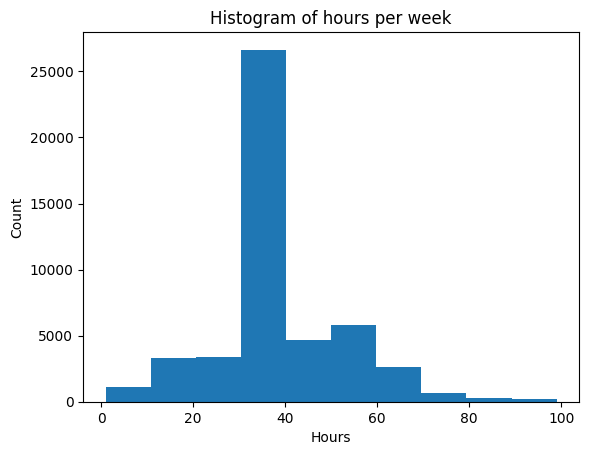

In [17]:
plt.hist(df['hours-per-week'])
plt.title('Histogram of hours per week')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

### Plot 2 — Histogram comparison

On a single figure, plot two histograms of `hours-per-week`:

* one for the `<=50K` class,
* one for the `>50K` class.

The histograms should be semi-transparent (set the `alpha` parameter).

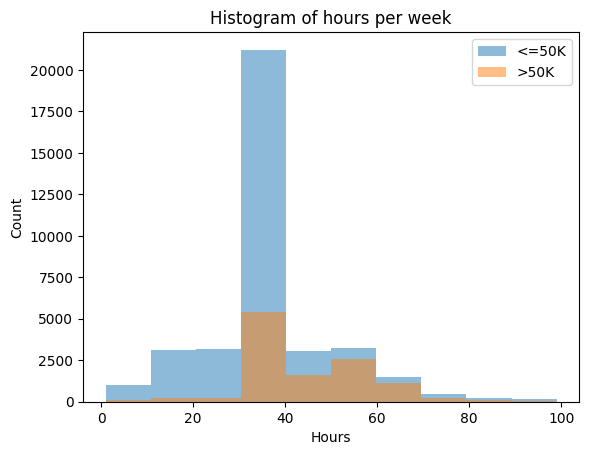

In [18]:
plt.hist(df[df['class'] == '<=50K']['hours-per-week'], alpha=0.5, label='<=50K')
plt.hist(df[df['class'] != '<=50K']['hours-per-week'], alpha=0.5, label='>50K')
plt.title('Histogram of hours per week')
plt.legend()
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

### Plot 3 — Bar chart

Create a bar chart showing the number of observations for each category of the `education` variable.

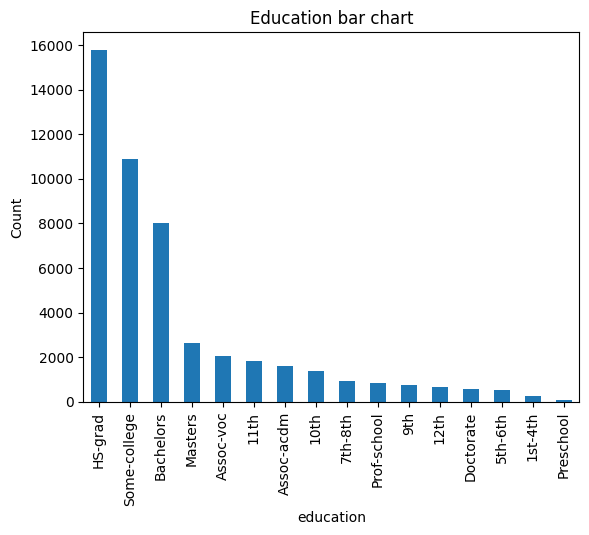

In [19]:
df['education'].value_counts().plot.bar()
plt.title('Education bar chart')
plt.ylabel('Count')
plt.show()

### Plot 4 — Scatter plot

Create a scatter plot where:

* the X-axis represents `capital-gain`,
* the Y-axis represents `hours-per-week`.

Set `alpha < 0.3`.

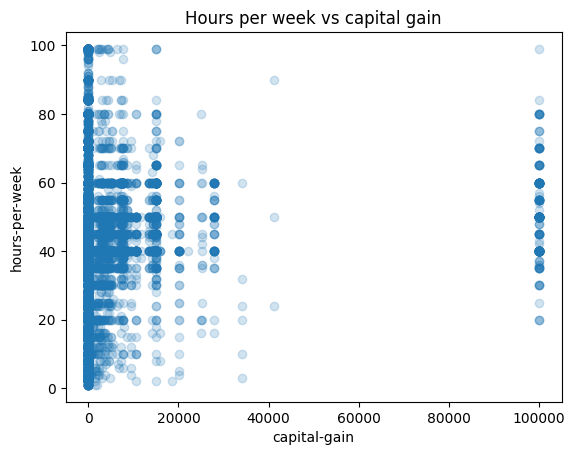

In [20]:
plt.scatter(df['capital-gain'], df['hours-per-week'], alpha=0.2)
plt.xlabel('capital-gain')
plt.ylabel('hours-per-week')
plt.title('Hours per week vs capital gain')
plt.show()

### Plot 5 — Logarithmic scale

Create a histogram of `capital-gain`.
Set the X-axis to a logarithmic scale.

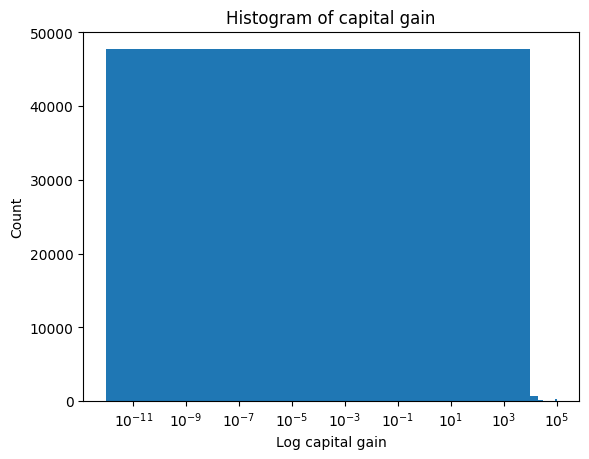

In [21]:
plt.hist(df['capital-gain'])
plt.xscale('log')
plt.title('Histogram of capital gain')
plt.xlabel('Log capital gain')
plt.ylabel('Count')
plt.show()

## 3. Data splitting — sklearn

Before splitting the data, separate:

* the feature matrix `X` (all columns except `class`),
* the target vector `y` (the `class` column).

In [22]:
X = df.drop(columns=['class'])
y= df['class']

### Task 1 — Train/validation/test split

1. Split the data into:

   * training set (60%),
   * validation set (20%),
   * test set (20%).

2. Use `train_test_split` with the `stratify=y` parameter to preserve class proportions.

3. Print the size of each split.

4. Print the class proportions in each split.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)
print(len(X_train))
print(len(X_val))
print(len(X_test))
print()
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

29305
9768
9769

class
<=50K    22293
>50K      7012
Name: count, dtype: int64
class
<=50K    7431
>50K     2337
Name: count, dtype: int64
class
<=50K    7431
>50K     2338
Name: count, dtype: int64


### Task 2 — Baseline model

The baseline model is a classifier that does not use input features and always predicts the majority class from the training set.

1. Determine the majority class in the training set.
2. Build a classifier that predicts this class for all test observations.
3. Compute the following metrics on the test set:

   * Accuracy,
   * Precision,
   * Recall,
   * F1.

You may implement this manually or use `DummyClassifier(strategy="most_frequent")`.

In [24]:
#Majority class is <=50K from data above
model = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       <=50K       0.76      1.00      0.86      7431
        >50K       0.00      0.00      0.00      2338

    accuracy                           0.76      9769
   macro avg       0.38      0.50      0.43      9769
weighted avg       0.58      0.76      0.66      9769



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 4. Pipeline — sklearn

### Task 1 — Preprocessing

1. Split the columns into numerical and categorical features.

2. Build a `ColumnTransformer` where:

   * numerical columns are processed with:

     * `SimpleImputer(strategy="median")`,
     * `StandardScaler`,
   * categorical columns are processed with:

     * `SimpleImputer(strategy="most_frequent")`,
     * `OneHotEncoder(handle_unknown="ignore")`.

3. Fit the preprocessing pipeline on the training set and check the shape of the transformed feature matrix.

In [25]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ct = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_transformed = ct.fit_transform(X_train)
print(f"Transformed shape: {X_train_transformed.shape}")

Transformed shape: (29305, 115)


### Task 2 — Logistic regression

1. Build a `Pipeline` consisting of:

   * preprocessing,
   * `LogisticRegression(max_iter=1000)`.

2. Train the model on the training set.

3. Compute the following metrics on the validation set:

   * Accuracy,
   * F1,

In [26]:
pipe = Pipeline([('ct', ct), ('logistic', LogisticRegression(max_iter=1000))])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.60      0.67      2337

    accuracy                           0.86      9768
   macro avg       0.81      0.77      0.79      9768
weighted avg       0.85      0.86      0.85      9768



## 5. GridSearch

### Task — Hyperparameter tuning for logistic regression

1. Define the parameter grid:

   * `C`: [0.01, 0.1, 1, 10].

2. Use `GridSearchCV` with:

   * `scoring="f1"`,
   * `cv=5`.

3. Fit the model on the training set.

4. Print the best parameters (`best_params_`) and the best cross-validation score (`best_score_`).

In [27]:
parameters = {'logistic__C': [0.01, 0.1, 1, 10]}

# Create a scorer that knows which label is positive
f1_scorer = make_scorer(f1_score, pos_label='>50K')

clf = GridSearchCV(pipe, parameters, scoring=f1_scorer, cv=5)

clf.fit(X_train, y_train)

print(f"Best parameters: {clf.best_params_}")
print(f"Best cross-validation F1 score: {clf.best_score_}")

Best parameters: {'logistic__C': 10}
Best cross-validation F1 score: 0.6547546446114645


## 6. MLP — PyTorch

In this section, use the data after preprocessing (the same transformations as in `sklearn`).

1. Fit the preprocessing pipeline on the training set.
2. Transform the training, validation, and test sets.
3. Convert the resulting matrices to `float32` tensors.
4. Encode the labels as 0 and 1.

---

### Task 1 — Network architecture

Build an MLP with the following structure:

* Input layer: number of neurons equal to the number of features after preprocessing.
* Hidden layer 1: `Linear(in_features, 128)` → `ReLU` → `Dropout(p=0.3)`.
* Hidden layer 2: `Linear(128, 64)` → `ReLU` → `Dropout(p=0.3)`.
* Hidden layer 3: `Linear(64, 32)` → `ReLU` → `Dropout(p=0.3)`.
* Output layer: `Linear(32, 1)`.

Do not apply a sigmoid activation inside the model.
Use `BCEWithLogitsLoss` as the loss function.

In [28]:
X_train_transformed = torch.tensor(ct.fit_transform(X_train).toarray(), dtype=torch.float32)
X_val_transformed = torch.tensor(ct.transform(X_val).toarray(), dtype=torch.float32)
X_test_transformed = torch.tensor(ct.transform(X_test).toarray(), dtype=torch.float32)


le = LabelEncoder().fit(y_train)
y_train_transformed = torch.tensor(le.transform(y_train), dtype=torch.float32)
y_test_transformed = torch.tensor(le.transform(y_test), dtype=torch.float32)
y_val_transformed = torch.tensor(le.transform(y_val), dtype=torch.float32)

In [29]:
X_test_transformed.shape

torch.Size([9769, 115])

In [64]:
model = nn.Sequential(
    nn.Linear(115, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(32, 1)
)

### Task 2 — Training

1. Use the `Adam` optimizer.

2. Apply a `StepLR` scheduler with `step_size=5` and `gamma=0.5`.

3. Implement early stopping with `patience=5`, monitoring the validation loss.

4. During each epoch, record:

   * training loss,
   * validation loss,
   * validation accuracy.

5. After training, plot training loss and validation loss as a function of epoch number.

In [65]:
patience = 5
criterion = nn.BCEWithLogitsLoss()
optim = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=5, gamma=0.5)

In [66]:
counter = patience
prev_loss = 9999999999999999
min_delta = 0.000001

training_losses = []
validation_losses = []
validation_acc = []


for epoch in range(50):
    optim.zero_grad()
    model.train()

    preds = model(X_train_transformed).squeeze()
    loss = criterion(preds, y_train_transformed)
    loss.backward()
    optim.step()
    print(f'Epoch: {epoch}')
    running_loss = loss.sum()
    print(f'Training loss: {running_loss:.7f}')
    training_losses.append(running_loss.item())

    model.eval()
    with torch.no_grad():
        preds = model(X_val_transformed).squeeze()
        loss = criterion(preds, y_val_transformed)
    running_loss = loss.sum()

    if prev_loss < running_loss + min_delta:
        counter -= 1
    else:
        counter = patience
    prev_loss = running_loss

    print(f'Validation loss: {running_loss:.7f}')
    validation_losses.append(running_loss.item())
    acc = ((preds > 0) == y_val_transformed).sum() / len(y_val_transformed)
    print(f'Validation accuracy: {acc:.4f}')
    validation_acc.append(acc.item())
    print()
    scheduler.step()
    if counter == 0:
        break


Epoch: 0
Training loss: 0.7355857
Validation loss: 0.6989613
Validation accuracy: 0.2429

Epoch: 1
Training loss: 0.6995374
Validation loss: 0.6526048
Validation accuracy: 0.7607

Epoch: 2
Training loss: 0.6522779
Validation loss: 0.5752345
Validation accuracy: 0.7607

Epoch: 3
Training loss: 0.5772001
Validation loss: 0.4922138
Validation accuracy: 0.7607

Epoch: 4
Training loss: 0.5036537
Validation loss: 0.4787716
Validation accuracy: 0.7607

Epoch: 5
Training loss: 0.4972205
Validation loss: 0.4656982
Validation accuracy: 0.7620

Epoch: 6
Training loss: 0.4834779
Validation loss: 0.4377080
Validation accuracy: 0.7663

Epoch: 7
Training loss: 0.4543779
Validation loss: 0.4117623
Validation accuracy: 0.7757

Epoch: 8
Training loss: 0.4287392
Validation loss: 0.3955643
Validation accuracy: 0.7922

Epoch: 9
Training loss: 0.4113735
Validation loss: 0.3887278
Validation accuracy: 0.8119

Epoch: 10
Training loss: 0.4037600
Validation loss: 0.3859631
Validation accuracy: 0.8193

Epoch: 11

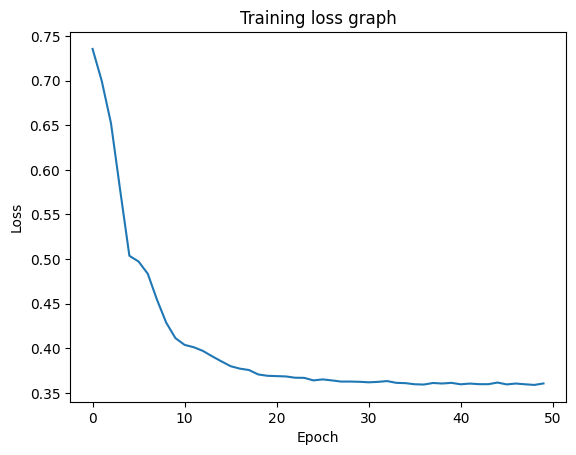

In [68]:
plt.plot(training_losses)
plt.title("Training loss graph")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

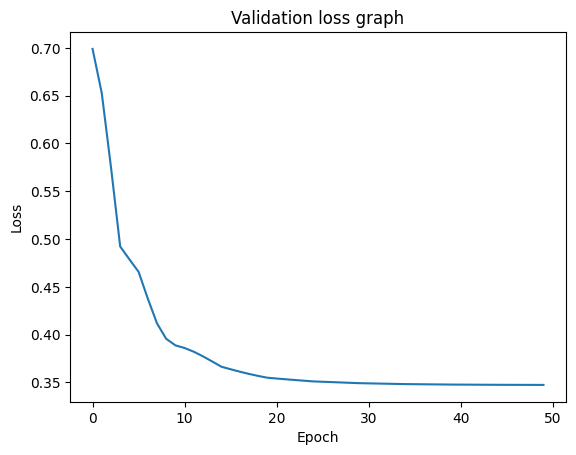

In [69]:
plt.plot(validation_losses)
plt.title("Validation loss graph")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### Task 3 — Evaluation

On the test set, compute:

* Accuracy,
* F1.

In [70]:
model.eval()
preds = model(X_test_transformed)
print(classification_report(y_test_transformed, preds > 0))

              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90      7431
         1.0       0.71      0.57      0.63      2338

    accuracy                           0.84      9769
   macro avg       0.79      0.75      0.77      9769
weighted avg       0.83      0.84      0.84      9769



## 7. Error analysis

1. Compute predicted probabilities for the positive class on the test set.
2. Identify:

   * 50 false positive cases with the highest predicted probability,
   * 50 false negative cases with the highest predicted probability.

In [71]:
preds = model(X_test_transformed)
probs = torch.sigmoid(preds)
probs[y_test_transformed == 1]


tensor([[0.5820],
        [0.2710],
        [0.5683],
        ...,
        [0.3125],
        [0.5545],
        [0.5477]], grad_fn=<IndexBackward0>)

In [96]:
#(probs > 0.5).squeeze() returns nothing, model is not that certain
#mask = torch.logical_and((probs > 0.5).squeeze(), (y_test_transformed == 0)).numpy()

mask = (y_test_transformed == 0).numpy()
_, sorted_indices = probs.sort(descending=True)
final_fp_indices = [idx.item() for idx in sorted_indices if mask[idx.item()]]
X_test.iloc[final_fp_indices[:50]]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,hours_bucket
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"
34333,54,Private,53407,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,"(30.4, 40.2]"


In [99]:
mask = torch.logical_and((probs < 0.5).squeeze(), (y_test_transformed == 1)).numpy()
_, sorted_indices = probs.sort(descending=False)
final_fp_indices = [idx.item() for idx in sorted_indices if mask[idx.item()]]
X_test.iloc[final_fp_indices[:50]]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,hours_bucket


## 8. Final report

In the final report, answer the following questions:

1. Which model achieved the highest F1 score?
2. Do the learning curves indicate a stable training process?
3. Did overfitting occur in the MLP model (compare training and validation loss)?

## 1. Logistic reggresion got 0.85 (0.01 more than mlp)
## 2. Yes
## 3. No